## Models

The model component in langChain is a crucial part of the framework, designed to facilitate interactions with various language models and embedding models

It abstracts the compexity of working directly with different LLMs,chat models and embedding models, providing a uniform interface to communicate with them. This makes it easier to build applications that rely on AI-Generated text, Embeddings for similarity search and RAG. 


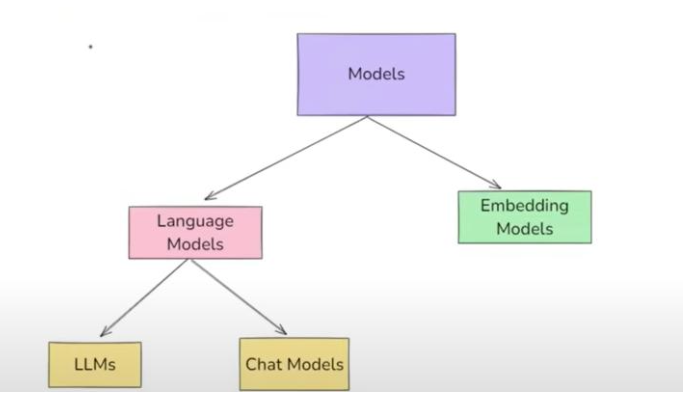

Model is an interface Through which you can interact with diff kinds of ai models...

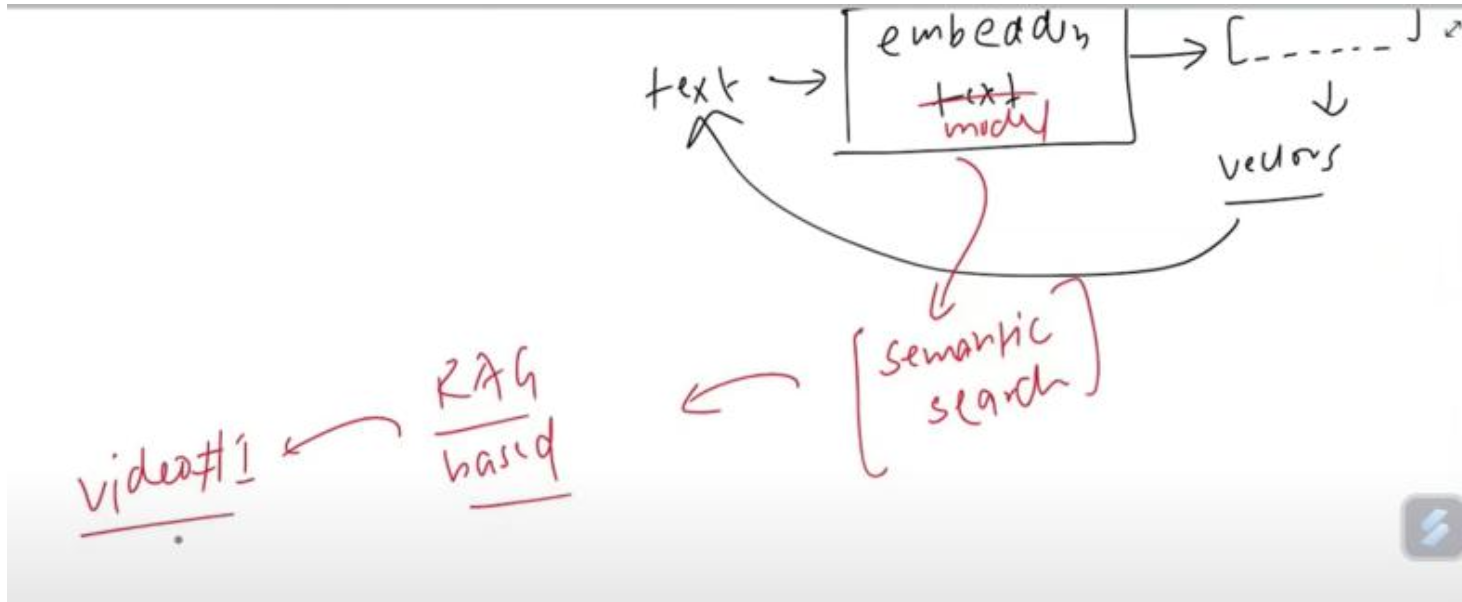

In [ ]:
# Plan of Action
# │l
# ├── Language Models
# │   ├── Closed Source
# │   │   ├── OpenAI
# │   │   ├── Claude
# │   │   └── Gemini
# │   │
# │   └── Open Source
# │       └── Hugging Face
# │
# └── Embeddings
#     ├── Closed Source
#     │   └── OpenAI
#     │
#     └── Open Source
#         └── Hugging Face

## Language Models

Language Models are AI Systems designed to process,generate and understand Natural Langugage text.



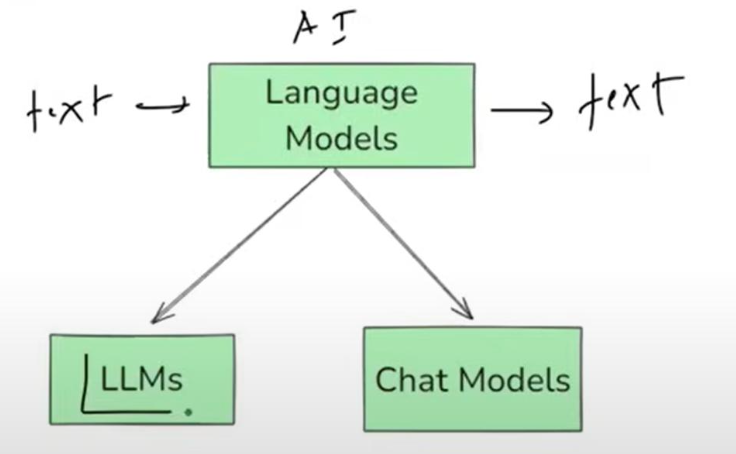

## LLMs

LLMs are general Purpose models. Used for raw text generation 

By general purpose we mean they can be used for text classification, text generation, code generation, Q/A, text summarization

Input: string , Output: string

## Chat Models

Language models specialized for conversational tasks.

Input: sequence of messages.

Output: sequence of messages 

These are tradionally newer models and used more in comparison to LLMs

Chatbots are special types of model used only for conversation..

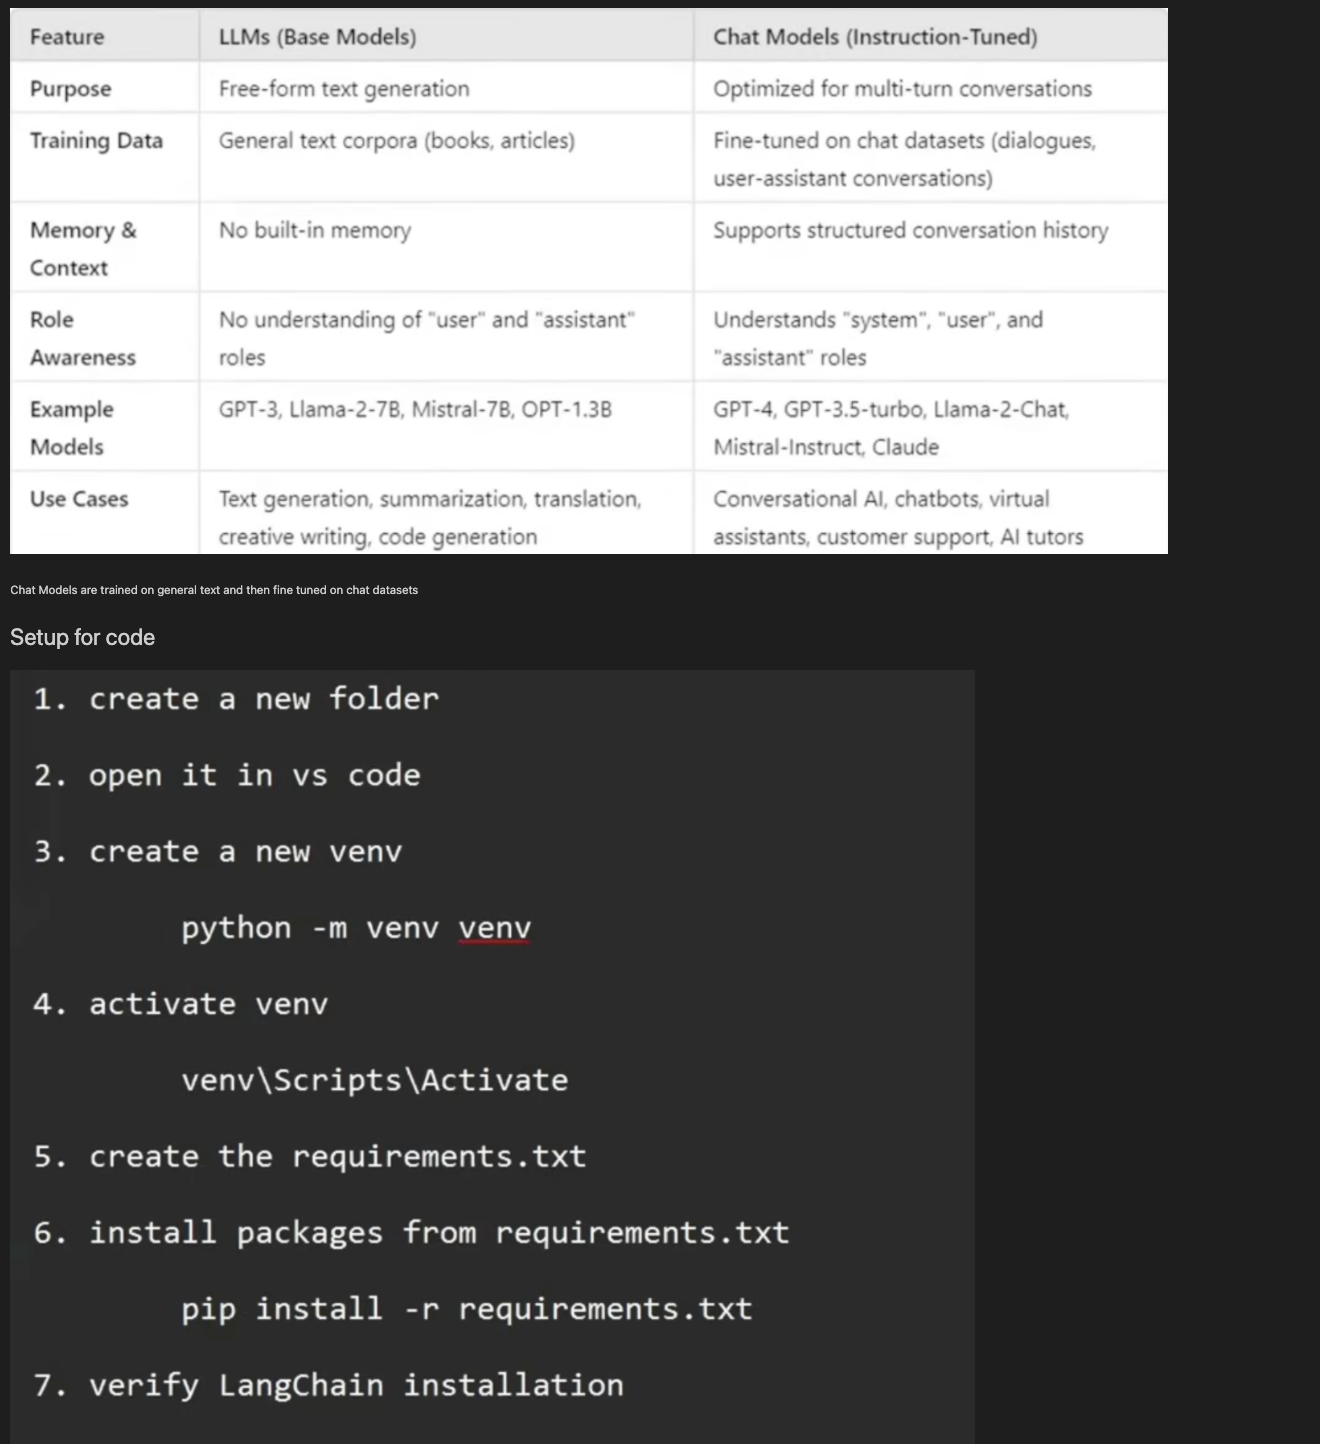

In [1]:
import langchain

langchain.__version__

'1.3.11'

## .env File
You create .env file in your project.

You store your secret keys here.

What is a .env file?

A .env file is simply a text file that stores environment variables.

Instead of writing your API key directly in your Python code,

❌ Bad Practice: api_key = "sk-proj-abc123456789"

you write it inside .env

OPENAI_API_KEY=sk-proj-abc123456789

This file is usually kept private and not uploaded to GitHub.

Project structure:

Project/

│

├── .env

├── app.py

├── requirements.txt

└── venv/


Dotenv file loads your env file into the current file.

Python itself cannot automatically read a .env file.

The package python-dotenv does that.

Install pip install python-dotenv

In [ ]:
from dotenv import load_dotenv
load_dotenv() ## This line reads the .env file and loads all variables into Python's environment.


## python can access it using 

import os
key=os.getenv("OPEN_API_KEY")


## LLMs

## 1. Openai

To get openAI api keys:

Go to url: platform.open.ai.com

Openai api keys are paid

Langchain_openai is integration package between LangChain and OpenAI.

In [2]:
# Your Code
#      │
#      ▼
# LangChain
#      │
#      ▼
# langchain_openai
#      │
#      ▼
# OpenAI API

## LangChain doesn't know how to call OpenAI directly.

langchain_openai

contains all the code required to:

1. send requests

2. receive responses

3. authenticate using API keys

4. convert LangChain objects into OpenAI API requests.

So it acts like a bridge.

In [3]:
from langchain_openai import OpenAI
## This imports the OpenAI LLM wrapper provided by LangChain.

## Creating an LLM

In [ ]:
llm=OpenAI(
    model="gpt-3.5-turbo-instruct"
)

# OpenAI() creates an object llm:
# stores:

# API key
# model name
# temperature
# max tokens
# timeout
# retries etc.

# It does not call OpenAI immediately.

# It only prepares the object.

## Invoke

You ask question inside invoke.

invoke() means Execute this model once using this input.

In [ ]:
result= llm.invoke("What is the capital of India?")


# Flow

# You :"What is capital of India?"
#         │
#    invoke()
#         │
#    OpenAI API
#         │
#     Response
#    "New Delhi"
# invoke() is now the standard method in LangChain.

# Older versions used llm.predict()

In [ ]:
print(result)
## output : New Delhi is the capital of India.

In [ ]:
# class OpenAI(BaseOpenAI):
#     """OpenAI completion model integration.

#     Setup:
#         Install `langchain-openai` and set environment variable `OPENAI_API_KEY`.

#         ```bash
#         pip install -U langchain-openai
#         export OPENAI_API_KEY="your-api-key"
#         ```

#     Key init args — completion params:
#         model:
#             Name of OpenAI model to use.
#         temperature:
#             Sampling temperature.
#         max_tokens:
#             Max number of tokens to generate.
#         logprobs:
#             Whether to return logprobs.
#         stream_options:
#             Configure streaming outputs, like whether to return token usage when
#             streaming (`{"include_usage": True}`).

#     Key init args — client params:
#         timeout:
#             Timeout for requests.
#         max_retries:
#             Max number of retries.
#         api_key:
#             OpenAI API key. If not passed in will be read from env var `OPENAI_API_KEY`.
#         base_url:
#             Base URL for API requests. Only specify if using a proxy or service
#             emulator.
#         organization:
#             OpenAI organization ID. If not passed in will be read from env
#             var `OPENAI_ORG_ID`.

#     See full list of supported init args and their descriptions in the params section.

#     Instantiate:
#         ```python
#         from langchain_openai import OpenAI

#         model = OpenAI(
#             model="gpt-3.5-turbo-instruct",
#             temperature=0,
#             max_retries=2,
#             # api_key="...",
#             # base_url="...",
#             # organization="...",
#             # other params...
#         )
#         ```

#     Invoke:
#         ```python
#         input_text = "The meaning of life is "
#         model.invoke(input_text)
#         ```
#         ```txt
#         "a philosophical question that has been debated by thinkers and scholars for centuries."
#         ```

#     Stream:
#         ```python
#         for chunk in model.stream(input_text):
#             print(chunk, end="|")
#         ```
#         ```txt
#         a| philosophical| question| that| has| been| debated| by| thinkers| and| scholars| for| centuries|.
#         ```

#         ```python
#         "".join(model.stream(input_text))
#         ```
#         ```txt
#         "a philosophical question that has been debated by thinkers and scholars for centuries."
#         ```

#     Async:
#         ```python
#         await model.ainvoke(input_text)

#         # stream:
#         # async for chunk in (await model.astream(input_text)):
#         #    print(chunk)

#         # batch:
#         # await model.abatch([input_text])
#         ```
#         ```txt
#         "a philosophical question that has been debated by thinkers and scholars for centuries."
#         ```
#     """  # noqa: E501

#     @classmethod
#     def get_lc_namespace(cls) -> list[str]:
#         """Get the namespace of the LangChain object.

#         Returns:
#             `["langchain", "llms", "openai"]`
#         """
#         return ["langchain", "llms", "openai"]

#     @classmethod
#     def is_lc_serializable(cls) -> bool:
#         """Return whether this model can be serialized by LangChain."""
#         return True

#     @property
#     def _invocation_params(self) -> dict[str, Any]:
#         return {"model": self.model_name, **super()._invocation_params}

#     @property
#     def lc_secrets(self) -> dict[str, str]:
#         """Mapping of secret keys to environment variables."""
#         return {"openai_api_key": "OPENAI_API_KEY"}

#     @property
#     def lc_attributes(self) -> dict[str, Any]:
#         """LangChain attributes for this class."""
#         attributes: dict[str, Any] = {}
#         if self.openai_api_base:
#             attributes["openai_api_base"] = self.openai_api_base

#         if self.openai_organization:
#             attributes["openai_organization"] = self.openai_organization

#         if self.openai_proxy:
#             attributes["openai_proxy"] = self.openai_proxy

#         return attributes

BaseOpenAI inherits from BaseLLM (Mother of all LLMs)

## Chat Models

Instead of plain text, you send messages.

Example

[
  HumanMessage(...),
  AIMessage(...),
  SystemMessage(...)
]

Now the model understands conversation.

System: You are a teacher.

Human: Explain AI.

Assistant: ...

Chat models understand

1. conversation

2. memory

3. roles

4. instructions

This is why almost all modern OpenAI models are chat models.

In current LangChain development, ChatOpenAI is generally preferred over the older OpenAI completion wrapper because modern OpenAI models are chat-based.

In [ ]:
from langchain_openai import ChatOpenAI

In [ ]:
# class ChatOpenAI(BaseChatOpenAI):  # type: ignore[override]
#     r"""Interface to OpenAI chat model APIs.

#     !!! warning "API scope"

#         `ChatOpenAI` targets
#         [official OpenAI API specifications](https://github.com/openai/openai-openapi)
#         only. Non-standard response fields added by third-party providers (e.g.,
#         `reasoning_content`, `reasoning_details`) are **not** extracted or
#         preserved. If you are pointing `base_url` at a provider such as
#         OpenRouter, vLLM, or DeepSeek, use the corresponding provider-specific
#         LangChain package instead (e.g., `ChatDeepSeek`, `ChatOpenRouter`).

#     ???+ info "Setup"

#         Install `langchain-openai` and set environment variable `OPENAI_API_KEY`.


BaseChatOpenAI inherits from BaseChatModel

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

In [ ]:
model=ChatOpenAI(model='gpt-4')

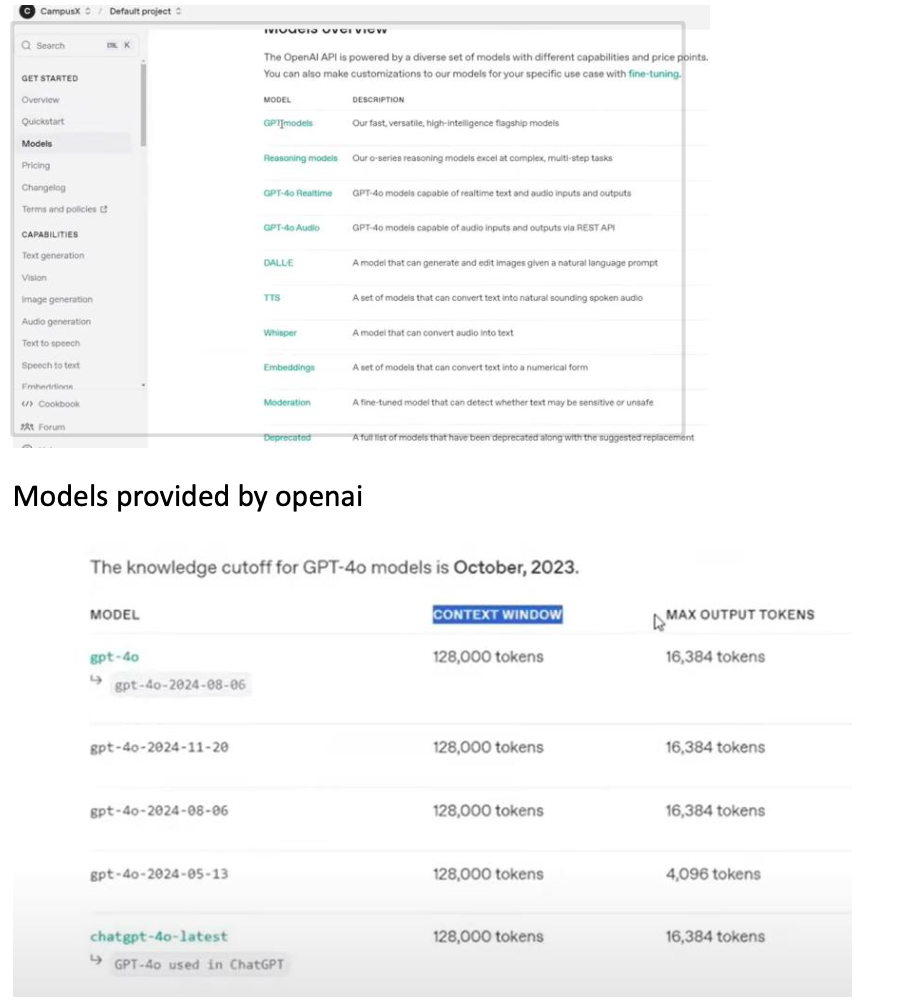

In [ ]:
result=model.invoke('What is the capital of India?')
print(result)

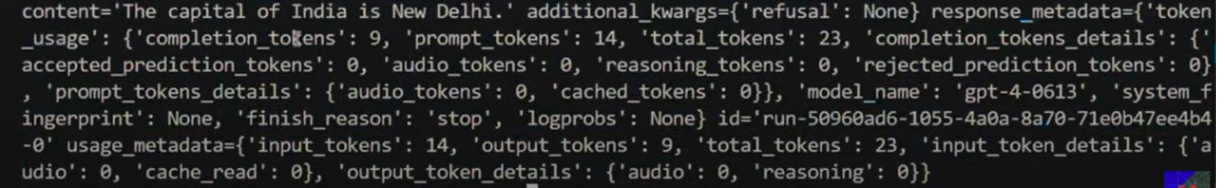

Instead of the string like in LLM we get this output, it gives you the answer along with the meta data


To print only the content:

In [ ]:
print(result.content)

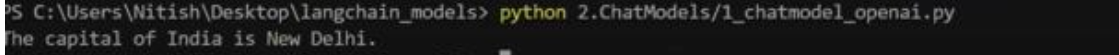

## Parameter setting

In [ ]:
model=ChatOpenAI(model='gpt-4',temperature=0,max_completion_tokens=500)
## shows creativitiy response 

result=model.invoke('Write a 5 line poem about Cricket ')
print(result.content)

## max_completion_tokens: how many max tokens I want as an output.
# As a developer I have to restrict my token that I don't want 
# LLM to product more than this max token range

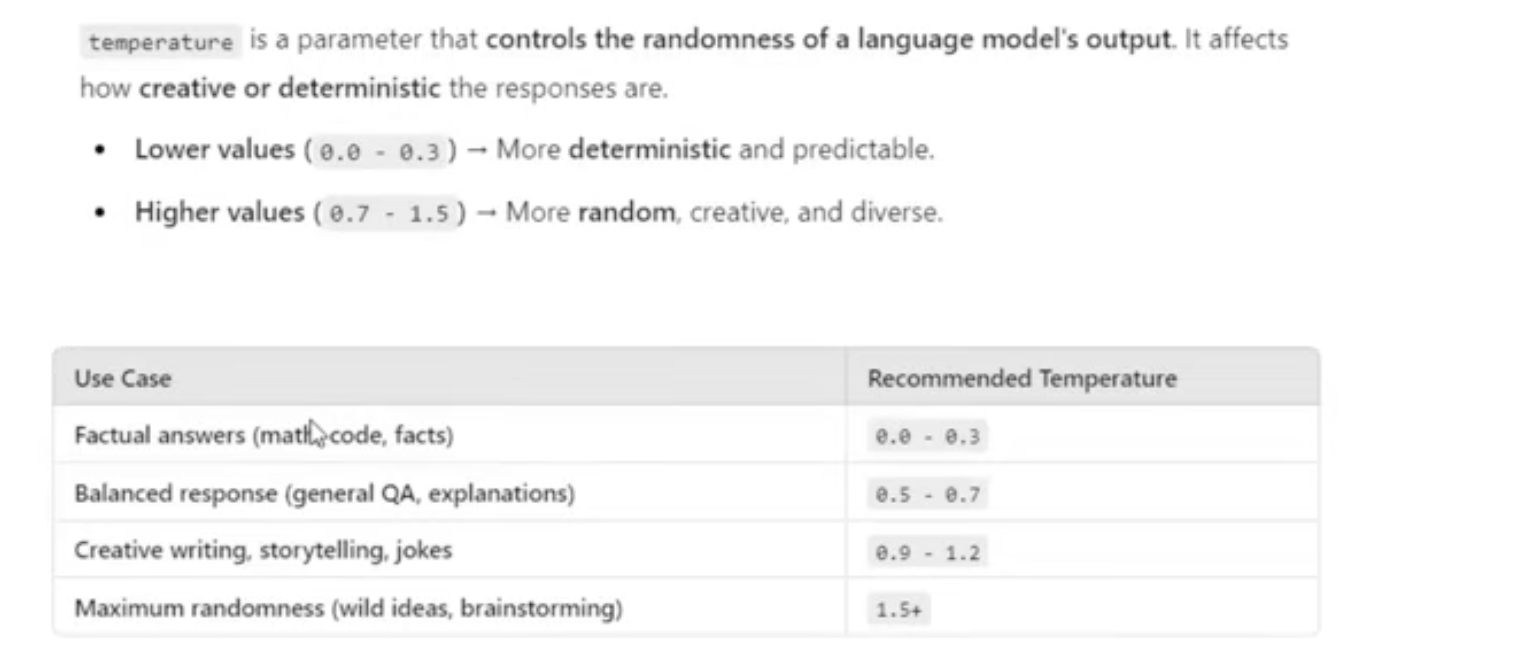

emperature in LLMs

Temperature = 0 → The model becomes highly deterministic and usually gives the same or very similar output for the same input.

Note: it does not guarantee identical output in every API/model because some systems can still have nondeterminism.

Temperature around 0 → Very little randomness; the output is generally consistent for the same input.

Temperature = 0.5 → Introduces some randomness. The same input may produce slightly different outputs on different runs.

Higher temperature → More randomness and creativity. The model is more likely to choose different words/tokens.

Temperature > 1.5 → Very high randomness (where the model/API allows such values), so the same input can produce substantially different outputs. It may also make responses less predictable or coherent.

In [ ]:
# Temperature
#      ↓
# Controls randomness in model output

# 0
# ↓
# Very deterministic / consistent

# 0.5
# ↓
# Some variation

# 1.0
# ↓
# More randomness

# 1.5+
# ↓
# High randomness / unpredictable

# LLM APIs generally use temperature (and sometimes a seed parameter, if supported) to control/reproduce generation

## Cluade (Anthropic)

In [ ]:
from langchain_anthropic import ChatAnthropic

load_dotenv()

model=ChatAnthropic(model='claude-3.5-sonnet-20241022',temperature=0)

result=model.invoke('What is the capital of India ?')

print(result.content)

## Gemini (Google GenerativeAI)

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

model=ChatGoogleGenerativeAI(model='gemini-1.5-pro')
result=model.invoke("What is the capital of India ?")
print(result.content)

## Open Source Models

What is a Language Model?

Before open-source vs closed-source, understand what a model actually is.

A language model is a neural network trained on huge amounts of text to learn patterns in language.

Example:

"What is the capital of India?" -> Language Model ->Output: "New Delhi is the capital of India."

Models such as Llama, Mistral, GPT, etc. contain billions of learned numerical parameters.

For example:

Llama 7B means approximately 7 billion parameters.

A parameter is essentially a learned numerical value inside the neural network.

In [ ]:
    #                 AI Models
    #                    │
    #          ┌─────────┴─────────┐
    #          │                   │
    #    Closed Source        Open Source/
    #                           Open-Weight
    #          │                   │
    #       GPT etc.          Llama, Mistral

# The main difference is:
# Who controls the model and how much of the model you can access/control?

In [ ]:
# Closed-Source Models
# Company ka model hota hai, company ke server pe pada hota hai.

# Consider a hypothetical model:
# Company X
#    │
#    ├── Model
#    ├── GPU servers
#    ├── Infrastructure
#    └── API

# You don't download the actual model. Instead, you communicate with the company's API.


from openai import OpenAI
client=OpenAI()

response=client.responses.create(
    model='some model',
    input='What is AI'
)

# Your Computer
#       │
#       │ API request
#       ▼
# Company's Server
#       │
#       ▼
#     Model
#       │
#       ▼
#    Response
#       │
#       ▼
# Your Computer

# The actual model runs on their infrastructure, not your laptop.

# Why do companies provide APIs?

# Suppose a company trained an enormous model requiring hundreds or thousands of GPUs.

# They obviously can't give every user the entire model.

# Instead, they expose an API.

# You send:

# "What is machine learning?"

# Their server runs the model and returns:

# "Machine learning is..."

# You pay according to usage or subscription/API pricing, depending on the service.

# So:

# You
#  ↓
# API
#  ↓
# Company's infrastructure
#  ↓
# Model
#  ↓
# Response

# Problems

1-Cost : Closed-source APIs can charge based on usage. Pricing depends on number of input tokens and output tokens . So if your application sends millions of requests, your API bill can become significant.

2-Less Control: Since model is on their server, we do not have power to change the model. You generally cannot directly modify the underlying neural-network weights.

You can usually control things like:

a. prompt , b.temperature, c.max output, d.system instructions, e.tools etc.

but you don't get unrestricted access to the model's internal parameters.

## Open Source Models

Organization train karke internet pe chhod deti hai and user can download it.


Open Source Models are freely available AI models that can be downloaded, modified, fine tuned, and deployed without restriction from a central provider. Unlike Closed source models like OpenAI's GPT-4, Antrhopic's Claude or Google's Gemini, open source models allow full control and customization

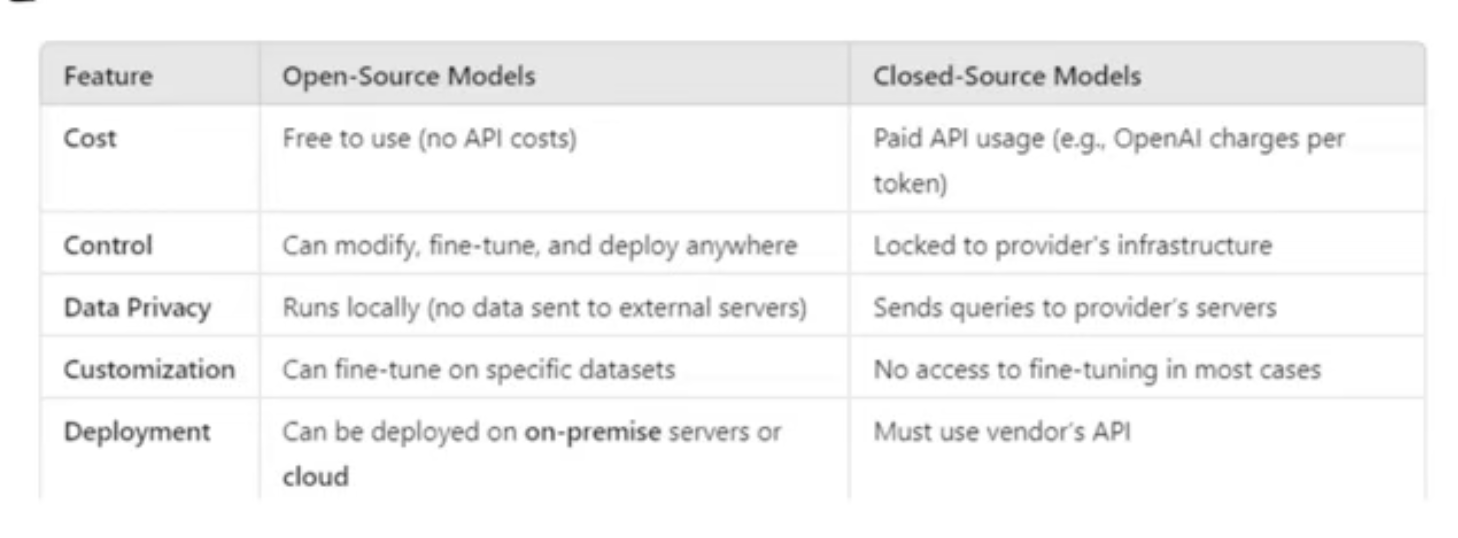

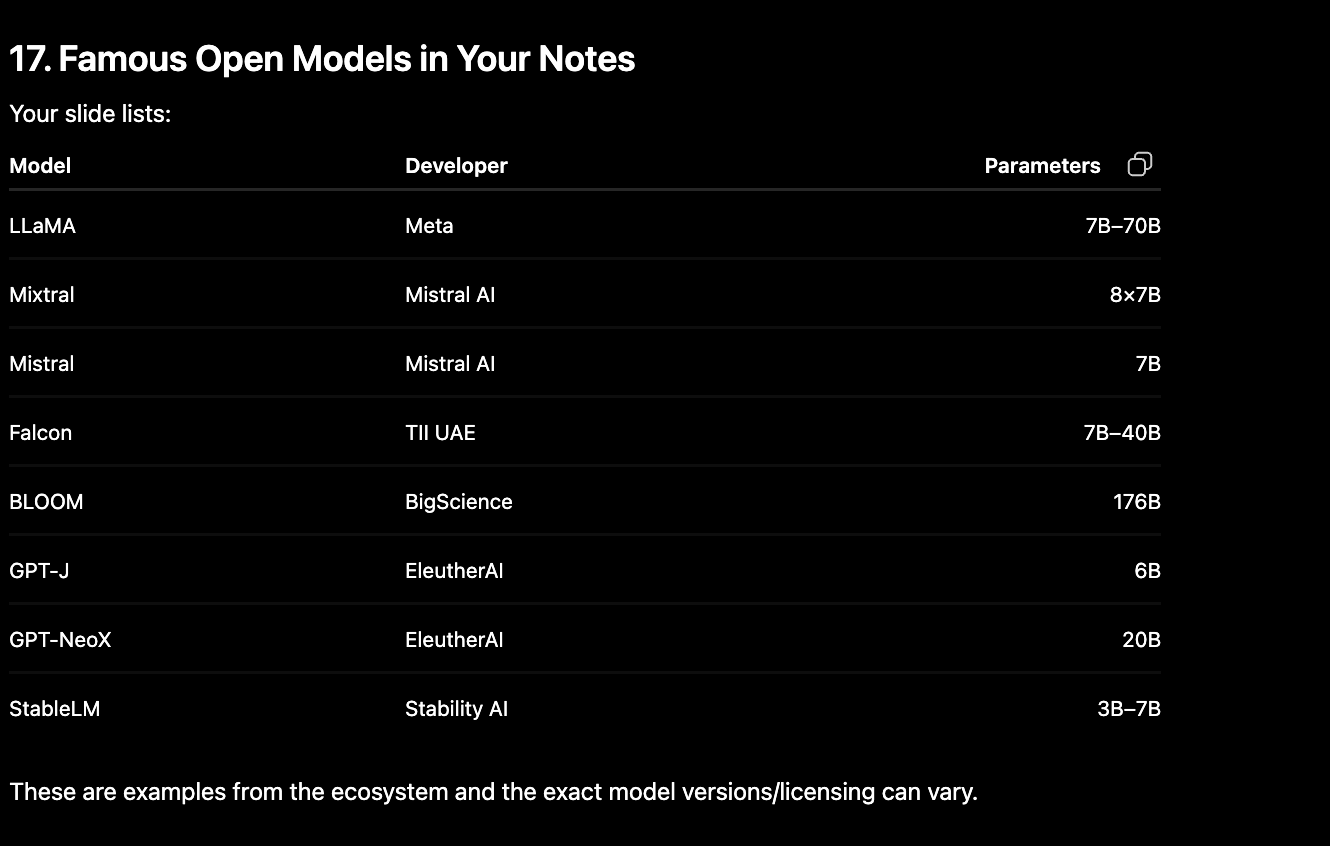

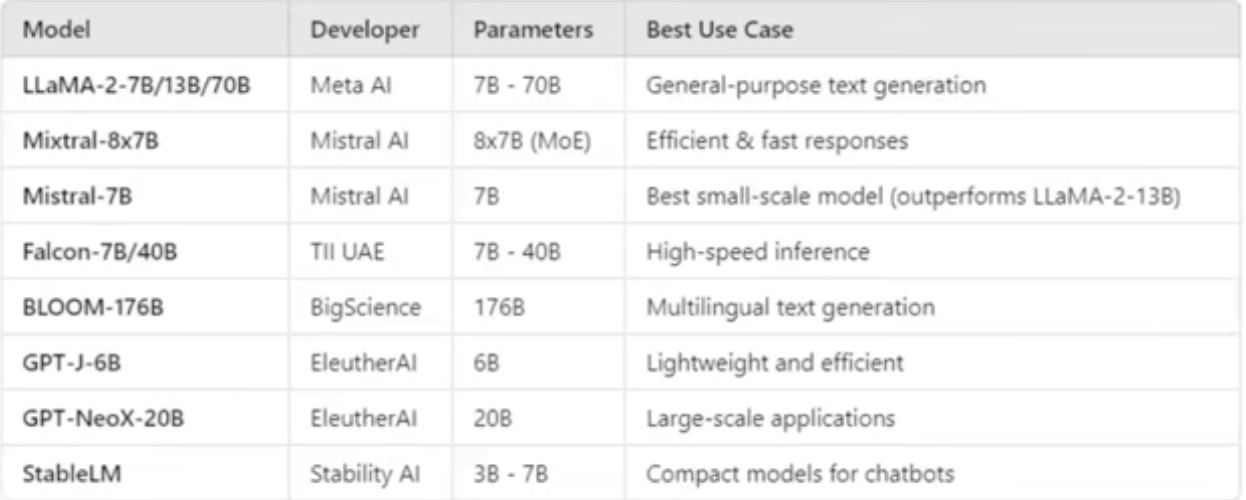

In [ ]:
# For AI models, there are several components:

# Model
# ├── Architecture
# ├── Source code
# ├── Weights
# ├── Training data
# ├── Training code
# └── License

# A model may release its weights without releasing all training data or every piece of training code.
# So when you see: "Open-source LLM" always check the actual license and what has been released.

# People often say "open-source model", 
# but many modern AI models are more accurately described as open-weight models.

## Where you can find Open Source Models ?

HuggingFace - The largest repository of open source models

Link- https://huggingface.co/models

You can find:

Models, Datasets, Tokenizers, Libraries, Spaces, Documentation

and models for:

NLP, Computer Vision, Audio, Multimodal AI, Generative AI etc.

In [4]:
# 21. Hugging Face Models

# For example, you might find a model repository containing:

# model/
# ├── config.json
# ├── tokenizer files
# ├── model weights
# └── README

# You can then use the model with libraries such as Transformers, subject to the model's license and hardware requirements.

In [ ]:
# 24. Multimodal Models

# Your notes say:

# Can send different types of input such as text, speech, audio, video.

# A multimodal model can process more than one modality.

# For example:

# Text
#   \
# Image ---> Multimodal Model ---> Text response
#   /
# Audio

# Depending on the specific model, it might accept combinations of:

# text
# images
# audio
# video

# Don't assume every multimodal model supports every modality; capabilities depend on the specific model.

## 2 Ways to use Open Source Models

1- Download the models from HuggingFace and run them locally 

2- Use API of HuggingFace and these APIs are free to use 

In [ ]:
# Hugging Face
#       ↓
# Download model
#       ↓
# Your machine/server
#       ↓
# Run model



# Instead of downloading the model, a service can host the model for you.
# Your Application
#        ↓
#       API
#        ↓
# Hosted Model
#        ↓
#    Response

# This means you don't need to manage:

# GPU
# model files
# inference server
# scaling
# infrastructure

# But you may have usage limits or charges depending on the provider/service.

# So the note:

# "Hugging Face APIs are free to use"

# should not be memorized as a universal rule. Availability, limits, and pricing can change, and individual hosted models/services may have different terms.

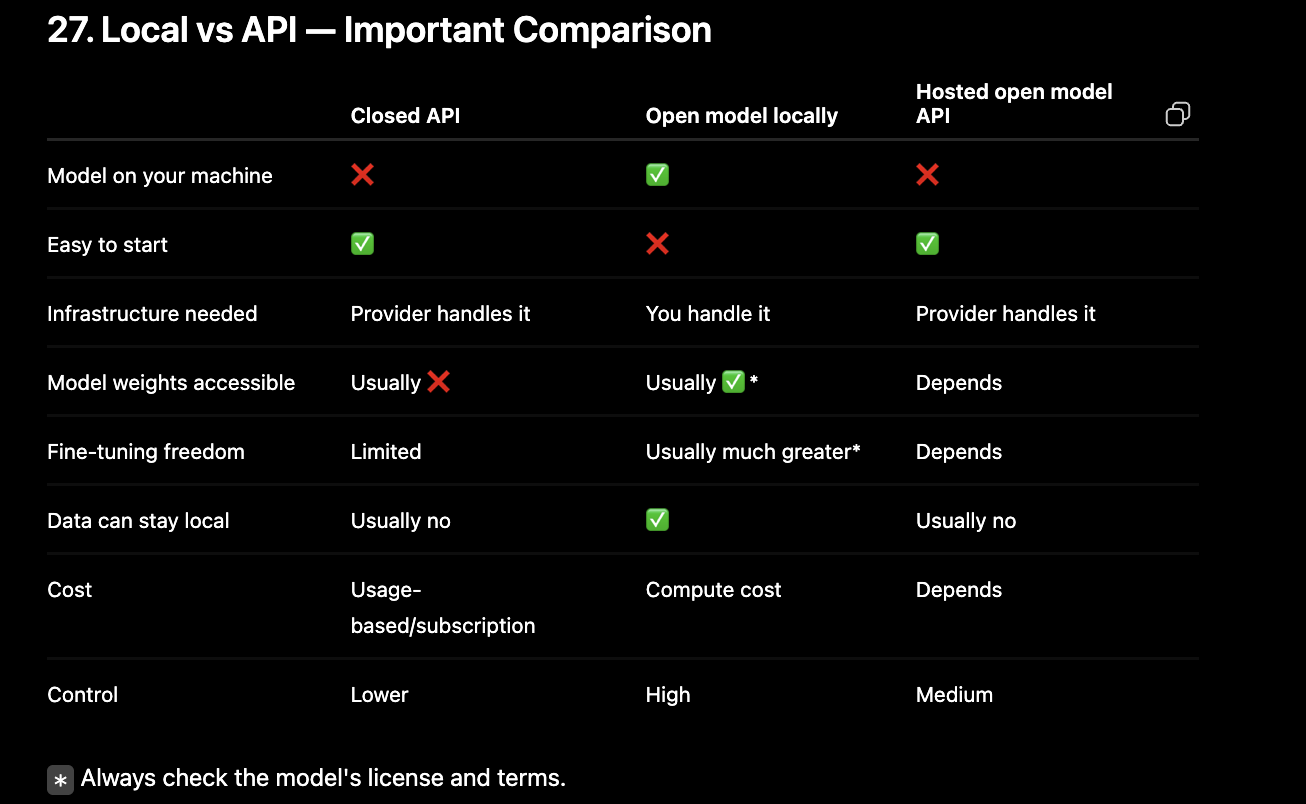

## How This Connects to LangChain

This is particularly important because you're learning LangChain. LangChain can provide a common interface to different model providers.

In [ ]:
# Conceptually:

#                     LangChain
#                        │
#           ┌────────────┼────────────┐
#           ↓            ↓            ↓
#        OpenAI       HuggingFace   Other LLMs
#           │            │
#           ↓            ↓
#     Closed API      Open Model

# So your application can be structured around LangChain abstractions 
# rather than writing completely different application logic for 
# every model provider.

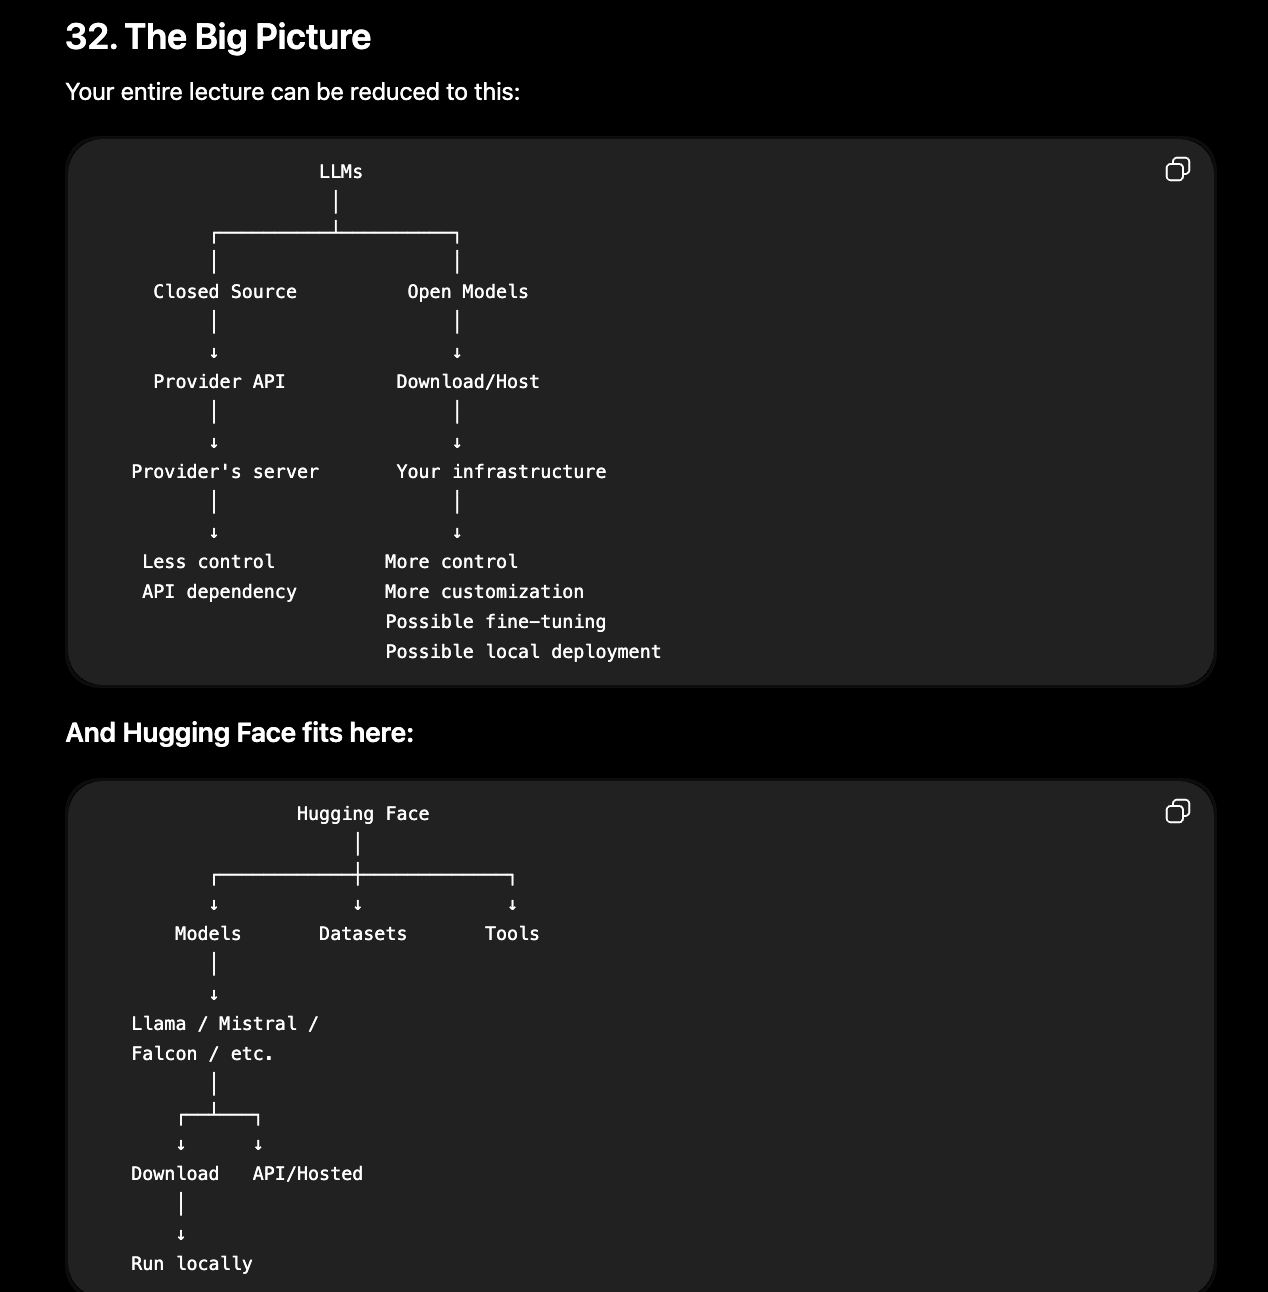

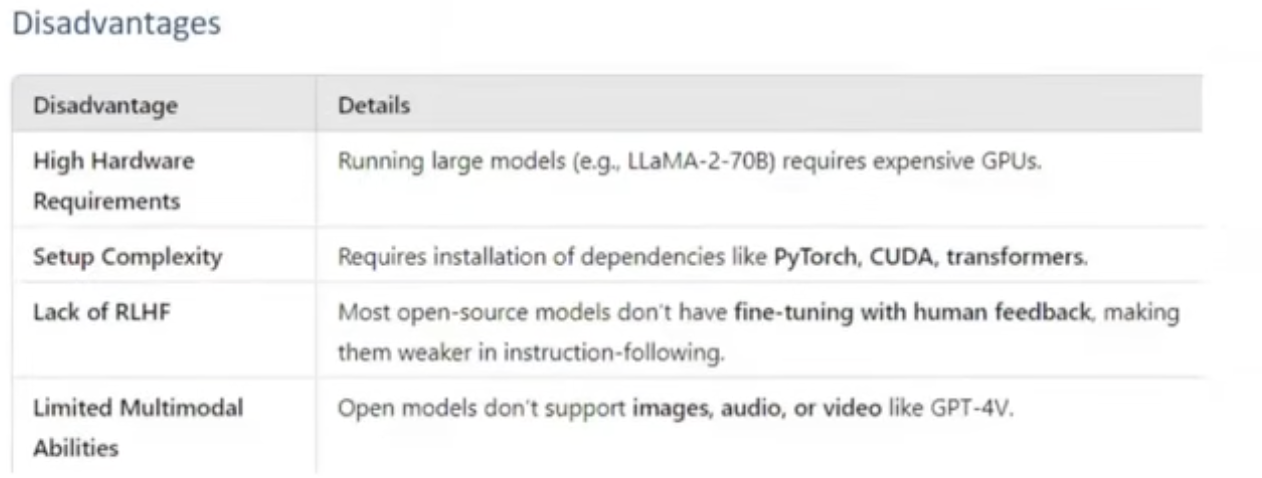

## Hugging Face Local API

Using API from the website of hugging face

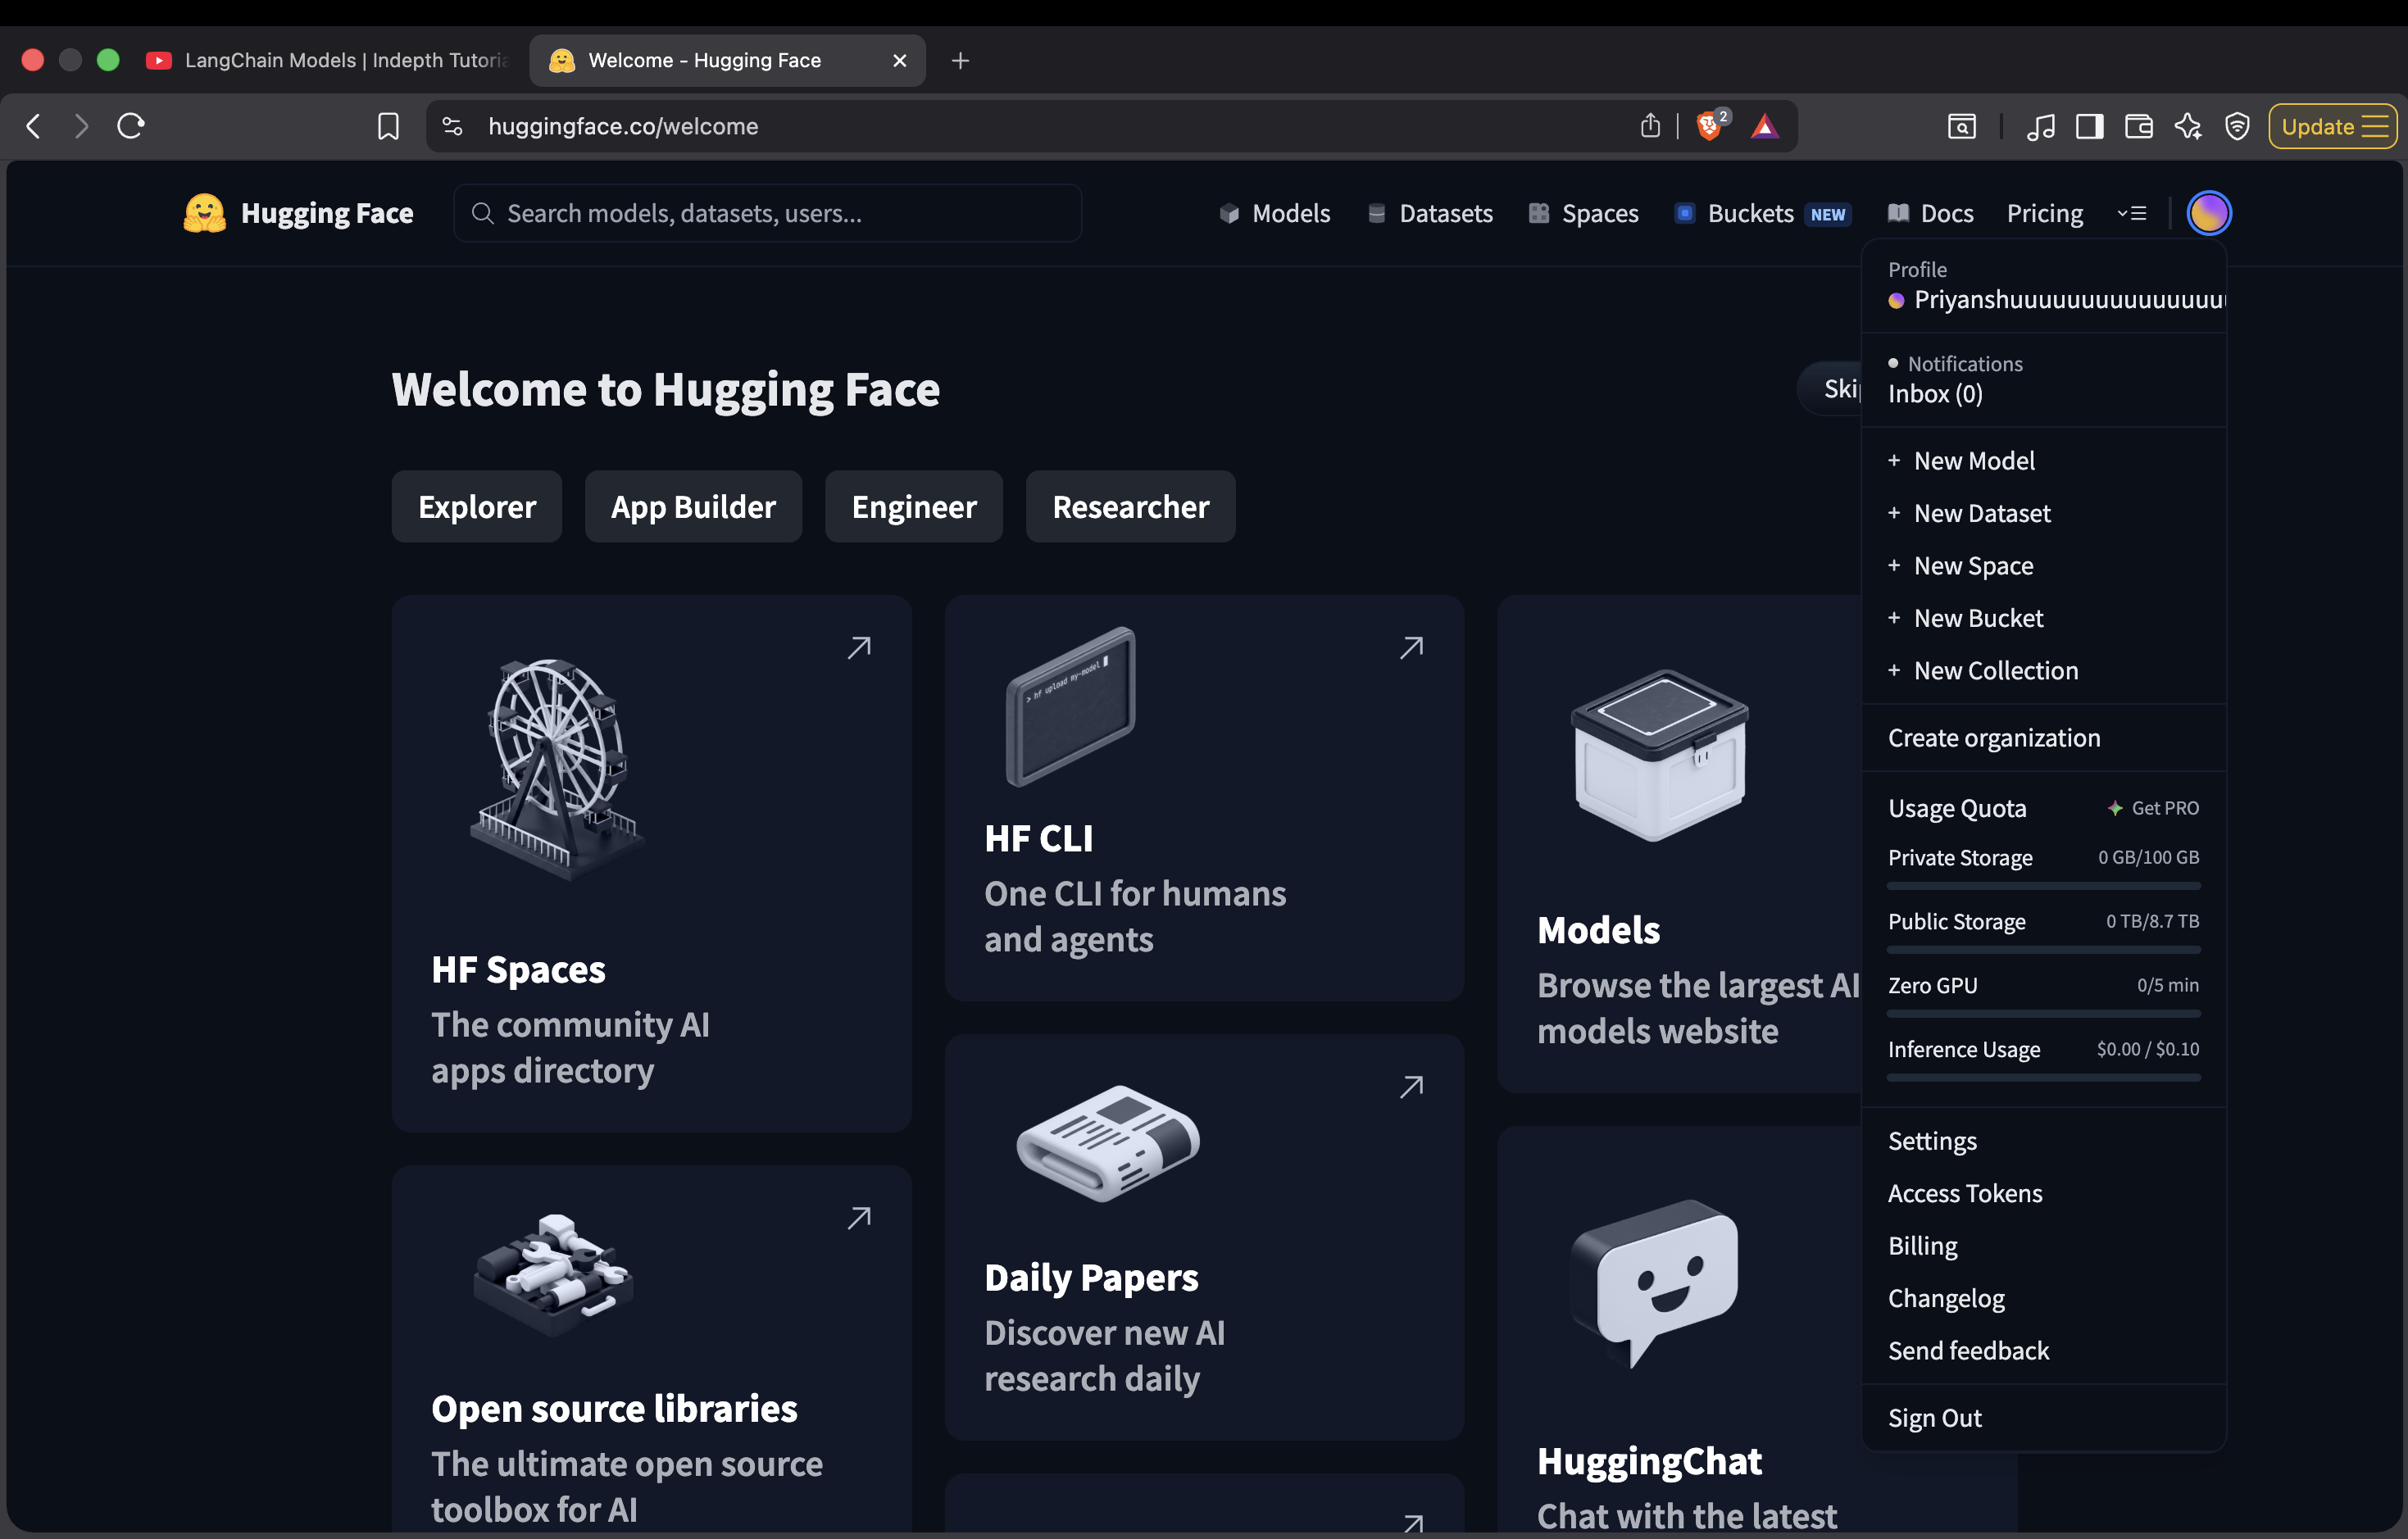


Go to access tokens

In [47]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

True

In [49]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

llm=HuggingFaceEndpoint(
    repo_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
    task='text-generation'
)

## repo_id: used to know which model of hugging face you are using 

## huggingface-> models -> choose model and copy it

In [ ]:
model=ChatHuggingFace(llm=llm)
result=model.invoke('what is capital of India')
print(result.content)

## HuggingFace local server

In [ ]:
from langchain_huggingface import ChatHuggingFace,HuggingFacePipeline

llm=HuggingFacePipeline.from_model_id(
    model_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
    task='text-generation',
                                      pipeline_kwargs=dict(
                                          temperature=0.5,
                                          max_new_tokens=100
                                      )
                                      )
model=ChatHuggingFace(llm=llm)

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
result=model.invoke('What is capital of India ?')
print(model.content)

## Embedding Models

In [ ]:
## will work with OpenAI and HuggingFace Embedding Models

## used to convert text to vector

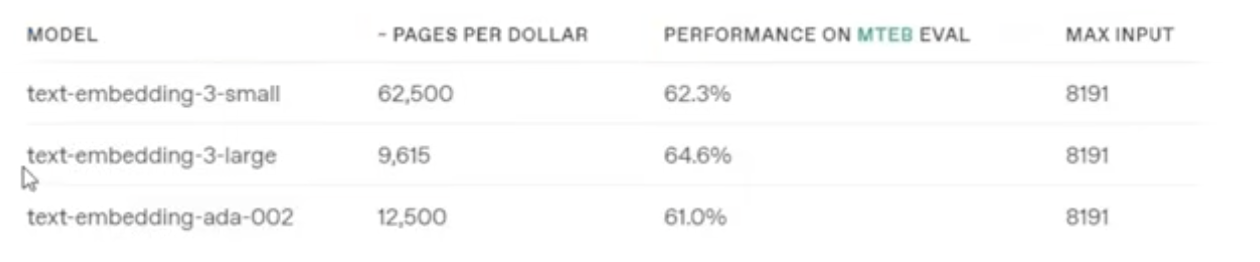

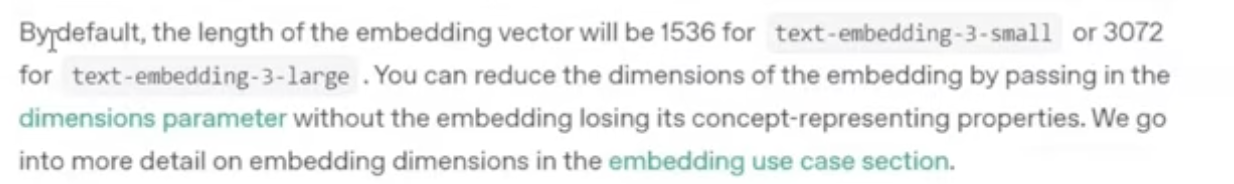

In [ ]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

In [ ]:
embedding=OpenAIEmbeddings(model='text-embedding-3-large',dimensions=32)

## performing embedding opeartions

result=embedding.embed_query("Delhi is the capital of India")

print(str(result))


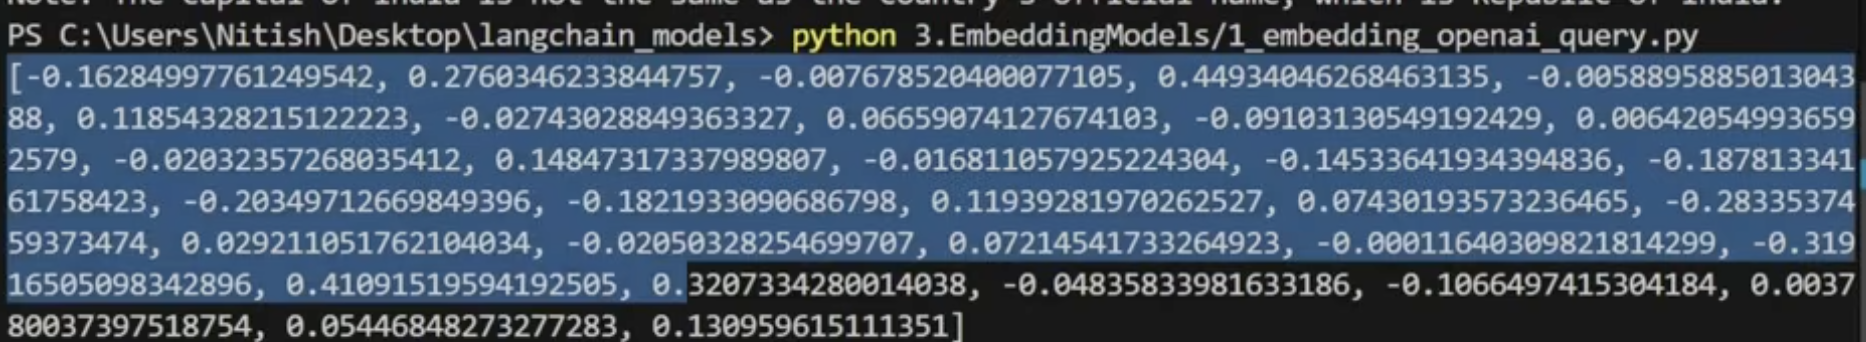

## Multiple Queries embedding

In [ ]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

In [ ]:
embedding=OpenAIEmbeddings(model='text-embedding-3-large',dimensions=32)

documents=[
    "Delhi is the capital of India",
    "Kolkata is the capital of West Bengal",
    "Jaipur is the capital of Rajasthan"
]

result=embedding.embed_documents(documents)

print(str(result))

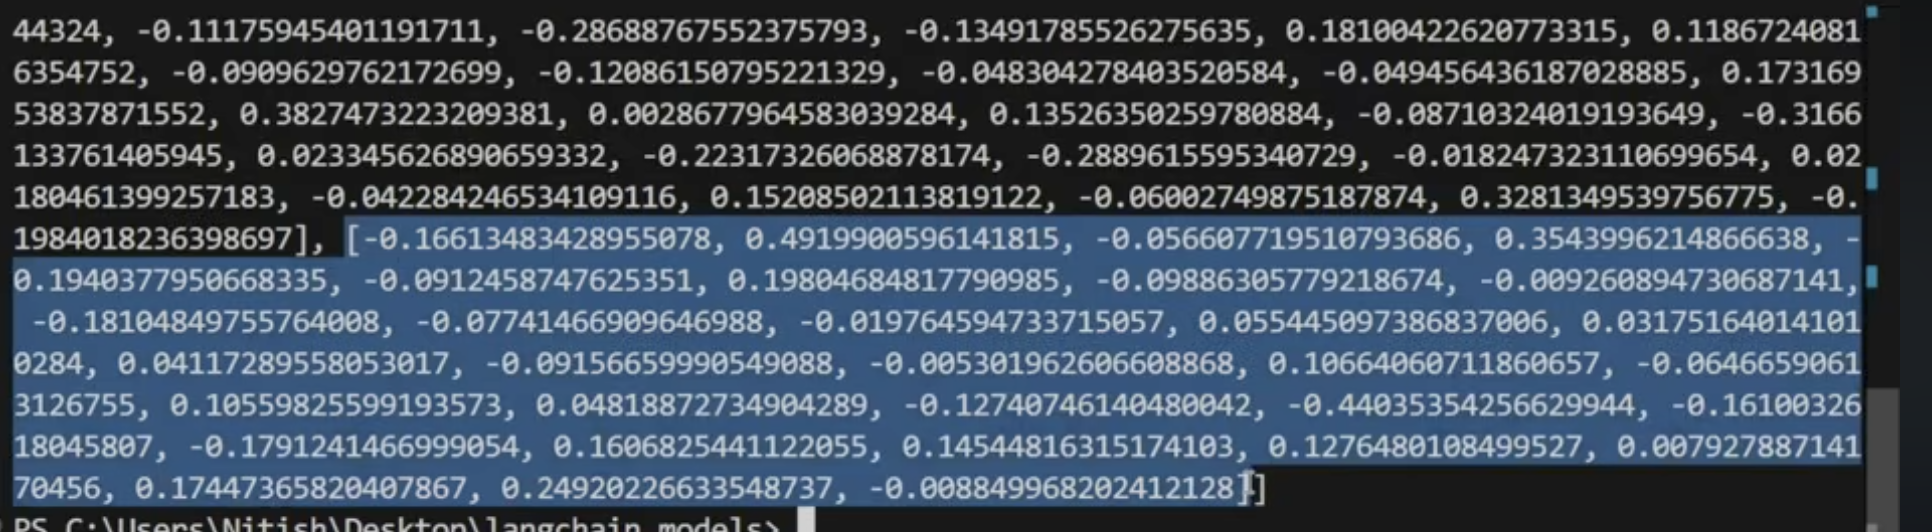

We get a 2D list

## Open Source model 

sentence-transformers/all-MiniLM-L6-v2

Maps sentences and paragraphs to 384 dimensions dense vector space

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

text="Delhi is the capital of India"

vector=embedding.embed_query(text)
print(str(vector))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[0.0435495488345623, 0.023877231404185295, -0.04524130001664162, 0.03540496900677681, -0.016651015728712082, -0.06554820388555527, 0.07626010477542877, 0.009940452873706818, -0.0019632333423942327, -0.027022702619433403, 0.007385597098618746, -0.12068236619234085, 0.06404842436313629, -0.06795037537813187, 0.03638886660337448, -0.07807774841785431, 0.03318416327238083, 0.08175564557313919, 0.07336154580116272, -0.07802223414182663, -0.020921166986227036, 0.03573280945420265, -0.008563265204429626, -0.037455134093761444, 0.0004388440283946693, 0.05346425250172615, 0.005293605383485556, -0.016870439052581787, -0.0004130426677875221, 0.0010301903821527958, 0.06669678539037704, 0.004223192576318979, -0.022522613406181335, -0.002101592253893614, -0.055947840213775635, 0.01686999201774597, -0.12951608002185822, 0.06496333330869675, 0.1728808730840683, -0.11778351664543152, 0.03644103556871414, -0.0006774854846298695, 0.07786678522825241, -0.028167499229311943, 0.036555320024490356, -0.023698

In [ ]:

documents=[
    "Delhi is the capital of India",
    "Kolkata is the capital of West Bengal",
    "Jaipur is the capital of Rajasthan"
]
result=embedding.embed_documents(documents)
print(str(result))

[[0.04354953020811081, 0.023877257481217384, -0.045241281390190125, 0.0354049950838089, -0.016651013866066933, -0.0655481368303299, 0.07626006752252579, 0.009940377436578274, -0.0019632000476121902, -0.027022650465369225, 0.007385602220892906, -0.12068243324756622, 0.06404844671487808, -0.06795039772987366, 0.036388881504535675, -0.07807774096727371, 0.03318416327238083, 0.0817556157708168, 0.07336153835058212, -0.07802222669124603, -0.020921217277646065, 0.03573279455304146, -0.008563325740396976, -0.03745511174201965, 0.00043886329513043165, 0.05346425995230675, 0.005293569527566433, -0.016870444640517235, -0.0004130355955567211, 0.00103013776242733, 0.06669677048921585, 0.004223215859383345, -0.022522680461406708, -0.0021016281098127365, -0.055947814136743546, 0.016869904473423958, -0.12951606512069702, 0.06496330350637436, 0.17288091778755188, -0.11778347194194794, 0.03644101321697235, -0.0006774636567570269, 0.07786678522825241, -0.028167519718408585, 0.036555398255586624, -0.0236

## Document similarlity Search Application

Document Similarity Search — Embedding Models

The main idea of this application is:

We have multiple documents and a user's question. We convert both the documents and the question into numerical vectors called embeddings, and then find which document is most similar to the question.

## 1. Problem Statement

Suppose we have 5 documents:

Document 1, Document 2, Document 3, Document 4, Document 5

A user asks:

"What is machine learning?"

We want to find:

Which document is most related to this question?

Instead of comparing the exact words, we use semantic similarity.

## 2. What is an Embedding?

An embedding is a numerical representation of text.

For example: "Machine learning is a branch of AI" is converted into something like:

[0.21, -0.43, 0.87, 0.12, ...]

This vector might have hundreds of dimensions.

Your diagram mentions:

300 dim

meaning the embedding model produces a vector containing 300 numerical values.


In [ ]:

# So:

# Text
#  ↓
# Embedding Model
#  ↓
# [0.21, -0.43, 0.87, ...]
#       ↑
#    300 numbers

## 3. Why Convert Text into Vectors?

Computers can easily perform mathematical operations on numbers.

They can't directly calculate: "cat" versus "kitten" for semantic similarity.

But after embeddings:

cat -> [0.2, 0.8, ...]

kitten -> [0.21, 0.79, ...]

Their vectors can be mathematically compared.

If two pieces of text have similar meanings, their embeddings tend to be close to each other in vector space.

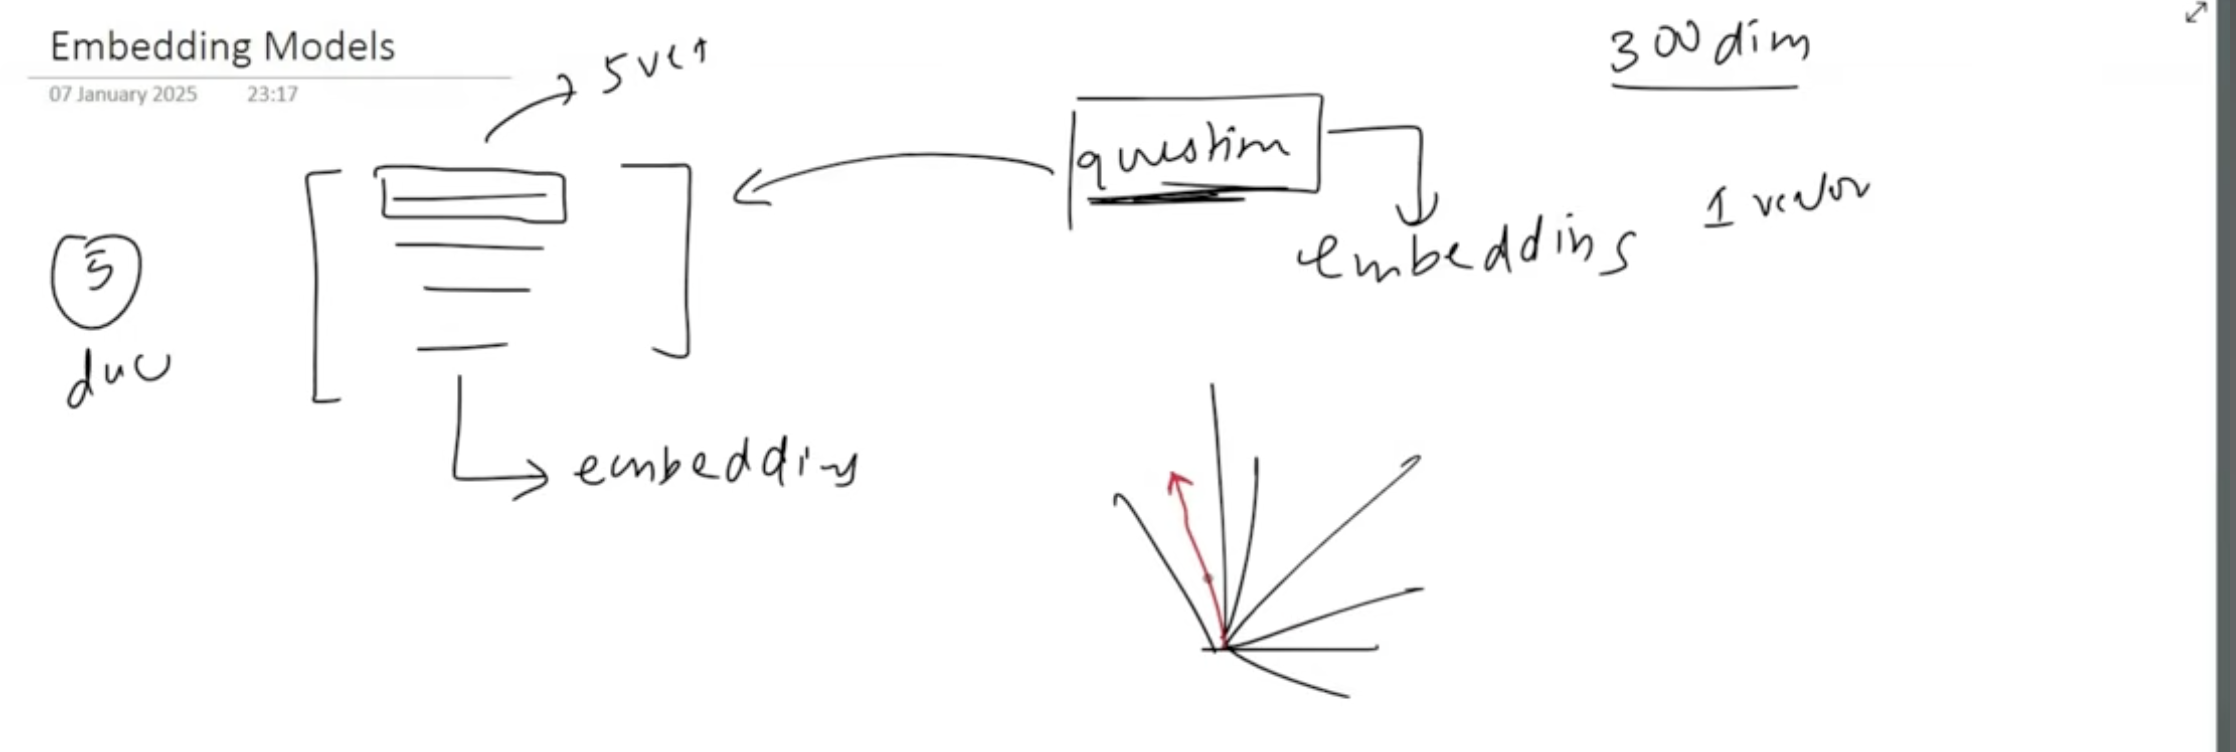

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

load_dotenv()

True

In [14]:
embedding=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

documents = [
    "Virat Kohli is an Indian cricketer known for his aggressive batting and leadership.",
    "MS Dhoni is a former Indian captain famous for his calm demeanor and finishing skills.",
    "Sachin Tendulkar, also known as the 'God of Cricket', holds many batting records.",
    "Rohit Sharma is known for his elegant batting and record-breaking double centuries.",
    "Jasprit Bumrah is an Indian fast bowler known for his unorthodox action and yorkers."
]


query='Tell me about Virat Kohli ?'

doc_embeddings=embedding.embed_documents(documents)
## we will have 5 vectors each of 300 dimensions

query_embedding=embedding.embed_query(query)
## we will have a single vector 


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [16]:
cosine_similarity([query_embedding],doc_embeddings)

array([[0.7880199 , 0.42814829, 0.48637292, 0.49452448, 0.39188891]])

In [17]:
scores=cosine_similarity([query_embedding],doc_embeddings)[0]

In [25]:
print(sorted(list(enumerate(scores)),key=lambda x: x[1] , reverse=True)[0])

(0, np.float64(0.78801990299534))


In [ ]:
index,score=sorted(list(enumerate(scores)),key=lambda x: x[1] , reverse=True)[0]
print(query)
print(documents[index])
print("similarity score is:",score)

Tell me about Virat Kohli ?
Virat Kohli is an Indian cricketer known for his aggressive batting and leadership.
similarity score is: 0.78801990299534
